In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
churn_data = pd.read_csv(r'C:\IDE\churn\churn\churn.csv')
display(churn_data.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


9.1. Cоотношение ушедших и лояльных клиентов

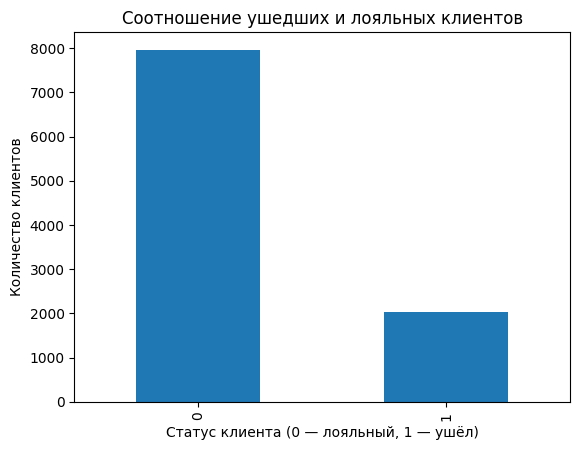

In [13]:
churn_data['Exited'].value_counts().plot(kind='bar')
plt.xlabel('Статус клиента (0 — лояльный, 1 — ушёл)')
plt.ylabel('Количество клиентов')
plt.title('Соотношение ушедших и лояльных клиентов')
plt.show()

Вывод: большинство клиентов остаются лояльными банку. Однако доля ушедших клиентов достаточно существенна, что указывает на необходимость работы с удержанием.

9.2.  Распределение баланса пользователей, у которых на счету больше 2 500 долларов

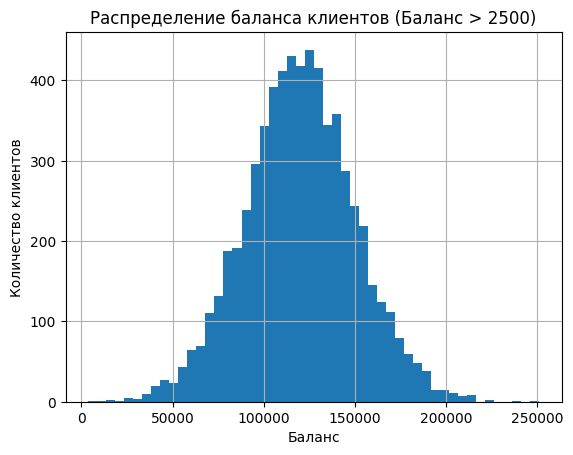

In [17]:
churn_data[churn_data['Balance'] > 2500]['Balance'].hist(bins=50)
plt.xlabel('Баланс')
plt.ylabel('Количество клиентов')
plt.title('Распределение баланса клиентов (Баланс > 2500)')
plt.show()

Вывод: Большинство клиентов сосредоточено в диапазоне средних значений, но присутствуют клиенты с очень крупными суммами на счетах.

9.3. Баланс клиент в разрезе признака оттока

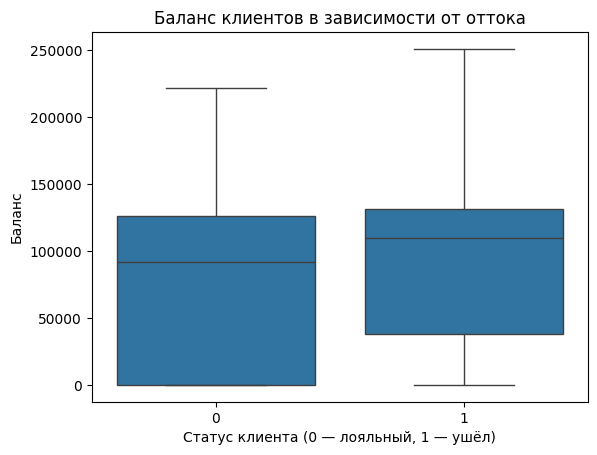

In [19]:
sns.boxplot(x='Exited', y='Balance', data=churn_data)
plt.xlabel('Статус клиента (0 — лояльный, 1 — ушёл)')
plt.ylabel('Баланс')
plt.title('Баланс клиентов в зависимости от оттока')
plt.show()

Вывод: Ушедшие клиенты в среднем имеют более высокий баланс. Это может говорить о том, что банк недостаточно эффективно работает с состоятельными клиентами

9.4. Возраст клиентов в разрезе оттока

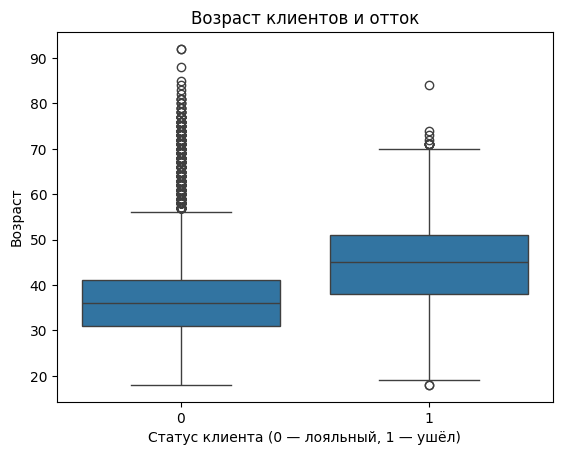

In [21]:
sns.boxplot(x='Exited', y='Age', data=churn_data)
plt.xlabel('Статус клиента (0 — лояльный, 1 — ушёл)')
plt.ylabel('Возраст')
plt.title('Возраст клиентов и отток')
plt.show()

Вывод: У ушедших клиентов больше потенциальных выбросов по возрасту. Особое внимание стоит уделить клиентам среднего и старшего возраста, где отток выражен сильнее.

9.5. Взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты.

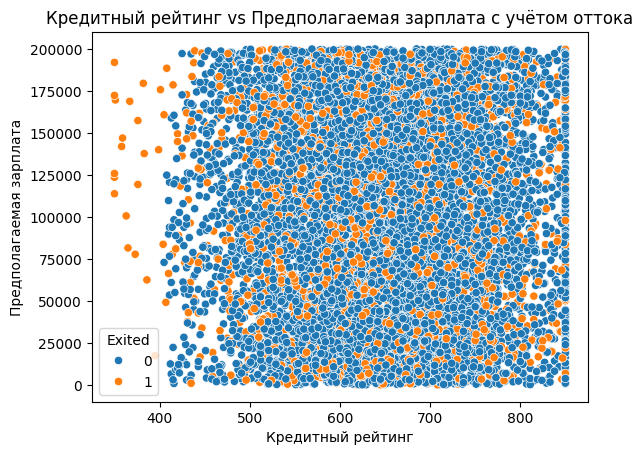

In [25]:
sns.scatterplot(x='CreditScore', y='EstimatedSalary', hue='Exited', data=churn_data)
plt.xlabel('Кредитный рейтинг')
plt.ylabel('Предполагаемая зарплата')
plt.title('Кредитный рейтинг vs Предполагаемая зарплата с учётом оттока')
plt.show()

Вывод: Явной зависимости между кредитным рейтингом и зарплатой не наблюдается. Отток клиентов распределён относительно равномерно.

9.6. Кто чаще уходит, мужчины или женщины

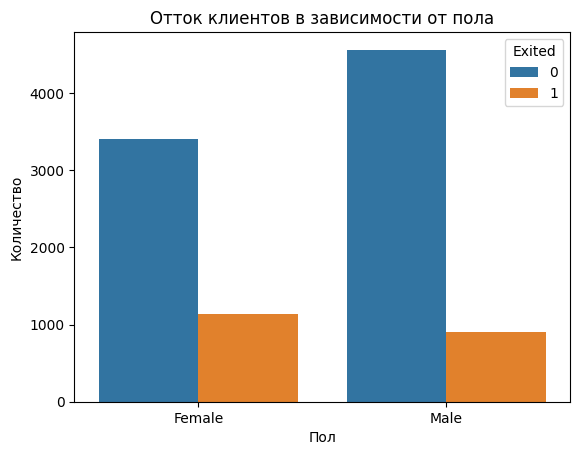

In [27]:
sns.countplot(x='Gender', hue='Exited', data=churn_data)
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.title('Отток клиентов в зависимости от пола')
plt.show()

Вывод: Женщины уходят из банка чаще мужчин. Это может быть связано с различиями в потребностях или уровне удовлетворённости банковскими продуктами.

9.7. Как отток клиентов зависит от числа приобретённых у банка услуг

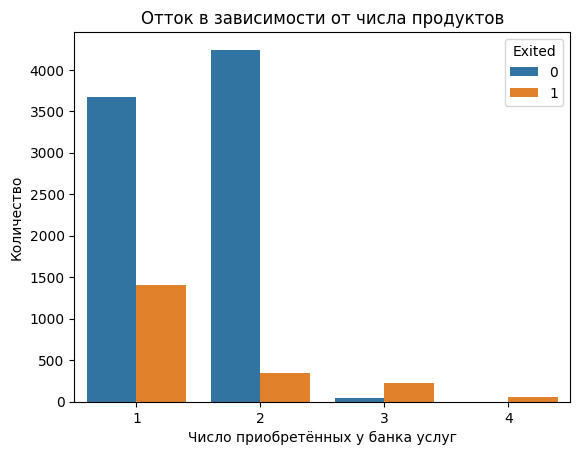

In [29]:
sns.countplot(x='NumOfProducts', hue='Exited', data=churn_data)
plt.xlabel('Число приобретённых у банка услуг')
plt.ylabel('Количество')
plt.title('Отток в зависимости от числа продуктов')
plt.show()

Вывод: Клиенты с меньшим количеством продуктов чаще уходят. Чем больше услуг использует клиент, тем выше его лояльность.

9.8.  Как влияет наличие статуса активного клиента на отток клиентов

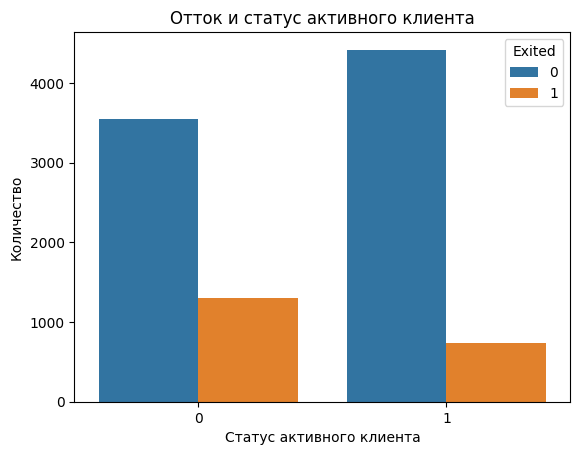

In [31]:
sns.countplot(x='IsActiveMember', hue='Exited', data=churn_data)
plt.xlabel('Cтатус активного клиента')
plt.ylabel('Количество')
plt.title('Отток и статус активного клиента')
plt.show()

Вывод: Неактивные клиенты значительно чаще уходят. Банку стоит внедрять программы вовлечения: бонусы, персональные предложения, акции.

9.9. В какой стране доля ушедших клиентов больше.

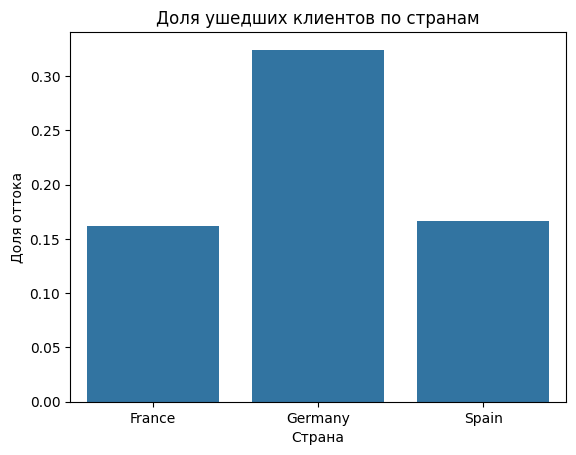

In [36]:
country_churn = churn_data.groupby('Geography')['Exited'].mean().reset_index()

sns.barplot(x='Geography', y='Exited', data=country_churn)
plt.title('Доля ушедших клиентов по странам')
plt.xlabel('Страна')
plt.ylabel('Доля оттока')
plt.show()

Вывод: В Германии доля оттока выше. Это может быть связано с региональной конкуренцией, экономическими условиями или спецификой сервиса в данной стране.

9.10. Кредитный рейтинг, срок и отток.

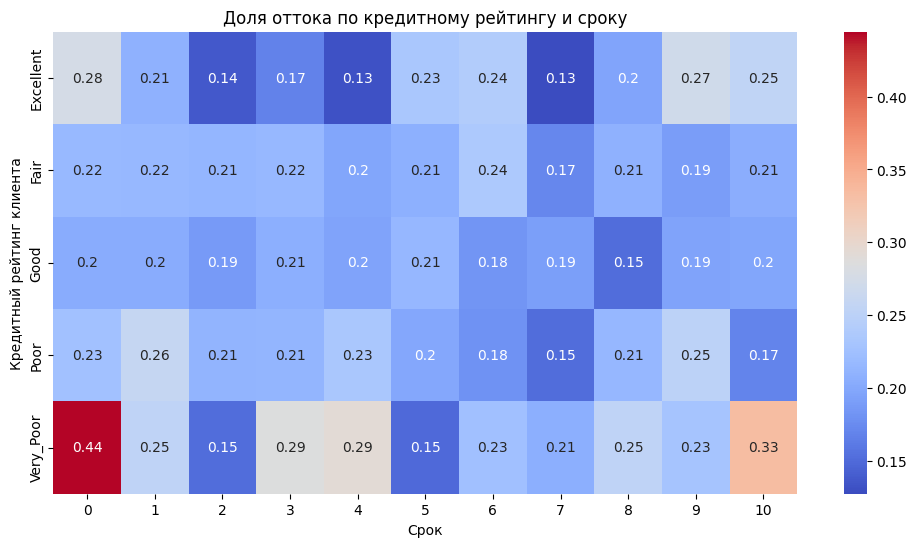

In [37]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

# создаём категориальный признак
churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

pivot = pd.pivot_table(
churn_data,
values='Exited',
index='CreditScoreCat',
columns='Tenure',
aggfunc='mean'
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Доля оттока по кредитному рейтингу и сроку')
plt.xlabel('Cрок')
plt.ylabel('Кредитный рейтинг клиента')
plt.show()

Вывод: Наибольший отток наблюдается у клиентов с низким кредитным рейтингом и небольшим сроком. Это ключевая группа риска, на которую банку стоит направить удерживающие меры.